                                           Disease Prediction using Machine Learning

In  the morden healthcare systems, hospital and clinics  are over corded , long patient wait times, lees Dr, 
medical staff. Paints come for  compalen bout the thier problem to Dr. and Dr. check
manually cross-referencing a patient's self-reported symptoms for finalaized the diease.
as well as  takes time nhuman error and cost for all medical test. 

Disease Prediction using Machine Learning with symptoms prognosis connect the model to real-world. 
Dataset Used :

Goal & Objectives

work flow

The model was trained on Training.csv and evaluated on Testing.csv.
1. Business Question
2. EDA
3. Feature Engineering
4. Baseline Model
5. Model Comparison
6. Hyperparameter Tuning
7. Final Model
8. Report
9. conculation
10. Business Interpretation

1.Business Question

Define the Business Objective
-------------------------------------------
Goal: Predict a patient’s disease based on reported symptoms and reduce time cost and reduce the long time waitng time.

Type: Multi-class classification problem.

# Business Question
------------------------------------------------------
i) How can a symptom-based a Machine Learning and Deep Learning prediction model help healthcare providers reduce diagnostic time and improve early disease detection accuracy?"

ii) How can providing a confidence score  for multiple diseases serve as a reliable decision-support tool for doctors?


Data Preparation Process
Since the dataset already includes separate training and testing sets, no additional train-test split was required.

The workflow :
Load Training.csv
Separate features (X) and target (y)
Encode the target variable
Train models on Training.csv
Evaluate performance on Testing.csv

MM odel:
Multinomial Logistic Regression (Base line model)
Model: Multinomial Regression,
 Random forest methods (xgboost)
Random Forest (Improved Model)
Gradient Boosting / XGBoost (Advanced Model)
Random forest methods (xgboost)
KNN clustering,
K-Means (Unsupervised Analysis)
Report: Accuracy,Precision,Recall,F1-score,Analyze confusion matrix
Discuss misclassified diseases


Deeplearing (ANN) Model :

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
#from xgboost import XGBClassifierr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings("ignore")


Reading the Dataset

In [3]:
train_df = pd.read_csv(r"C:\Users\amena\DSI\Disease_Prediction_With_ML\data\Training.csv")
test_df = pd.read_csv(r"C:\Users\amena\DSI\Disease_Prediction_With_ML\data\Testing.csv")

In [4]:
train_df.head(5)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [4]:
test_df.head(5)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Allergy
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,GERD
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chronic cholestasis
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Drug Reaction


In [5]:
print(train_df.shape)
print(test_df.shape)

(4920, 134)
(42, 133)


2.EDA – Exploratory Data Analysis

In [6]:
#is they are balance the data
print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 4920
Test size: 42


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), str(1)
memory usage: 5.0 MB


In [8]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Columns: 133 entries, itching to prognosis
dtypes: int64(132), str(1)
memory usage: 43.8 KB


In [9]:
train_df.select_dtypes(include="object").columns

Index(['prognosis'], dtype='str')

In [9]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

4616
0


In [10]:
print(train_df.columns)
print(test_df.columns)

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis',
       'Unnamed: 133'],
      dtype='str', length=134)
Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'blackheads', 'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis'],
      dtype='str', length=133)


In [11]:
train_df.isnull().sum()  #missing value

itching                    0
skin_rash                  0
nodal_skin_eruptions       0
continuous_sneezing        0
shivering                  0
                        ... 
blister                    0
red_sore_around_nose       0
yellow_crust_ooze          0
prognosis                  0
Unnamed: 133            4920
Length: 134, dtype: int64

In [360]:
test_df.isnull().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

In [12]:
print("Train distribution:")
print(train_df.value_counts())

print("\nTest distribution:")
print(test_df.value_counts())

Train distribution:
Series([], Name: count, dtype: int64)

Test distribution:
itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  muscle_wasting  vomiting  burning_micturition  spotting_ urination  fatigue  weight_gain  anxiety  cold_hands_and_feets  mood_swings  weight_loss  restlessness  lethargy  patches_in_throat  irregular_sugar_level  cough  high_fever  sunken_eyes  breathlessness  sweating  dehydration  indigestion  headache  yellowish_skin  dark_urine  nausea  loss_of_appetite  pain_behind_the_eyes  back_pain  constipation  abdominal_pain  diarrhoea  mild_fever  yellow_urine  yellowing_of_eyes  acute_liver_failure  fluid_overload  swelling_of_stomach  swelled_lymph_nodes  malaise  blurred_and_distorted_vision  phlegm  throat_irritation  redness_of_eyes  sinus_pressure  runny_nose  congestion  chest_pain  weakness_in_limbs  fast_heart_rate  pain_during_bowel_movements  pain_in_anal_region  bloody_

In [ ]:
# Clean unnecessary empty columns (like 'Unnamed: 133')

train_df.drop(columns=train_df.filter(regex="^Unnamed").columns, inplace=True)
test_df.drop(columns=test_df.filter(regex="^Unnamed").columns, inplace=True)

In [14]:
# after unnamed is droped the train data set
print(train_df.shape)
print(test_df.shape)

(4920, 133)
(42, 133)


In [15]:
print(train_df.columns.str.contains("Unnamed").any())

False


In [105]:
train_df["prognosis"].value_counts()

prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hep

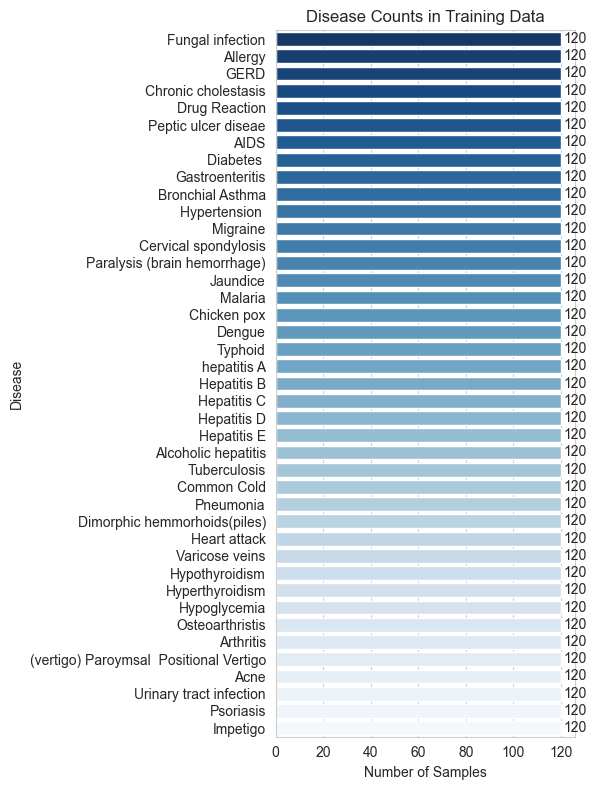

In [ ]:

#plot 
counts = train_df["prognosis"].value_counts().sort_values()

plt.figure(figsize=(6, 8))

ax = sns.barplot(
    x=counts.values,
    y=counts.index,
    palette=sns.color_palette("Blues_r", len(counts))
)

# add numbers
for i, v in enumerate(counts.values):
    ax.text(v + 1, i, str(v), va="center")

plt.title("Disease Counts in Training Data")
plt.xlabel("Number of Samples")
plt.ylabel("Disease")

plt.tight_layout()
plt.show()

3. Data Preparation & Features engineeirng
#---------------------------------------------------------------

In [ ]:
# # Separate Features (X) and Target (y)
# #one way
# X_train = train_df.drop(columns=['prognosis'])
# y_train_text = train_df['prognosis']

# X_test = test_df.drop(columns=['prognosis'])
# y_test_text = test_df['prognosis']

In [84]:
from imblearn.over_sampling import SMOTE

# 2nd way
X = train_df.drop(columns=['prognosis'])
y = train_df['prognosis']

sm = SMOTE()
X_over, y_over = sm.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_over,
    y_over,
    random_state=42,
    shuffle=True,
    test_size=0.2
)

In [ ]:
# #3rd way

# #sklearn.model_selection import train_test_split

# X = train_df.drop(columns=['prognosis'])
# y = train_df['prognosis']

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     shuffle=True
# )

In [85]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [86]:
print(le.transform(["Fungal infection"]))

[15]


In [87]:
print(X_train.shape)
print(y_train.shape)

(3936, 132)
(3936,)


In [88]:
#Model 1: Multinomial Logistic Regression
# ultinomial Logistic Regression is a classification algorithm used when the target variable has more than two classes.

multinomial_model = LogisticRegression(
    #multi_class='multinomial', 
    solver='lbfgs',  ##lbfgs automatically uses multinomial for multi-class problems
    max_iter=1000, 
    C=1.0, 
    random_state=42
)
multinomial_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [89]:
# Predict & Evaluate
y_pred = multinomial_model.predict(X_test)

In [90]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        25
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        23
           6       1.00      1.00      1.00        33
           7       1.00      1.00      1.00        23
           8       1.00      1.00      1.00        21
           9       1.00      1.00      1.00        15
          10       1.00      1.00      1.00        23
          11       1.00      1.00      1.00        26
          12       1.00      1.00      1.00        21
          13       1.00      1.00      1.00        29
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        19
          16       1.00      1.00      1.00        28
          17 

In [ ]:
# KNN Baseline Model Code

In [91]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [92]:
# 1. Initialize the KNN model
# n_neighbors=5 means it will look at the 5 most similar patients to make a decision
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')


In [93]:
# 2. Train the model
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [94]:
# 3. Predict on the Testing Data
y_pred_knn = knn_model.predict(X_test)


In [96]:
# 4. Evaluate the model
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Baseline Accuracy: {acc_knn * 100:.2f}%\n")

KNN Baseline Accuracy: 100.00%



In [97]:
# 5. Detailed Classification Report
print("Detailed Classification Report (KNN):")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

Detailed Classification Report (KNN):
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        18
                                   AIDS       1.00      1.00      1.00        30
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        25
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        23
                       Bronchial Asthma       1.00      1.00      1.00        33
                   Cervical spondylosis       1.00      1.00      1.00        23
                            Chicken pox       1.00      1.00      1.00        21
                    Chronic cholestasis       1.00      1.00      1.00        15
                            Common Cold       1.00      1.00      1.00

In [98]:
#Model _2 XGBoost (Gradient Boosting)

xgb_model = XGBClassifier(
    objective='multi:softprob', # Multi-class classification
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict & Evaluate
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {acc_xgb * 100:.2f}%\n")

XGBoost Accuracy: 100.00%



In [99]:
 #Define the base XGBoost model
xgb_base = XGBClassifier(
    objective='multi:softprob', # Multi-class classification
    eval_metric='mlogloss',
    random_state=42
)

In [100]:
# 2. Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],       # Number of trees
    'learning_rate': [0.01, 0.1, 0.2],    # Step size shrinkage
    'max_depth': [3, 5, 7],               # Maximum depth of a tree
    'subsample': [0.8, 1.0]               # Fraction of observations to be randomly sampled for each tree
}


In [103]:
# 3. Initialize GridSearchCV
# cv=3 means 3-fold cross-validation. n_jobs=-1 uses all CPU cores for faster processing.
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,         
    n_jobs=-1,    
    verbose=1     
)

In [326]:
# 4. Fit the Grid Search to the Training Data
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [312]:
# 5. Get the best model and print the best parameters
best_xgb_model = grid_search.best_estimator_
print("\nBest Hyperparameters Found:")
print(grid_search.best_params_)


Best Hyperparameters Found:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [313]:
# 6. Predict & Evaluate using the optimized model on the Testing Data
y_pred_xgb_best = best_xgb_model.predict(X_test)
acc_xgb_best = accuracy_score(y_test, y_pred_xgb_best)

In [314]:
# Optional: Print detailed classification report for the tuned model
from sklearn.metrics import classification_report
print("Detailed Classification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_xgb_best, target_names=le.classes_))

Detailed Classification Report (Tuned XGBoost):
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       0.50      1.00      0.67         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00

## Random Foresst
#----------------------------------------------

In [327]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [328]:
#Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [329]:

# Predict & Evaluate
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {acc_rf * 100:.2f}%\n")

Random Forest Accuracy: 97.62%



In [330]:
# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [331]:

# Parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [332]:
# GridSearch
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

In [334]:
print("Best RF Parameters:", grid_rf.best_params_)
print("Best RF CV Score:", grid_rf.best_score_)


Best RF Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV Score: 1.0


In [335]:
from sklearn.metrics import accuracy_score, classification_report

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

In [336]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9761904761904762
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      0.50      0.67         2
          16       1.00      1

Model comparison :

predicting prognosis = disease category, this is a classification problem so  we do the.
Logistic Regression models the probability that a patient has a specific disease based on their symptoms. 
It applies a softmax function to transform linear combinations of symptoms into class probabilitie

Even though Logistic Regression perfectly solved this specific dataset, real-world medical data is never this clean. In a real hospital setting, patients forget to report symptoms, report the wrong symptoms, or have overlapping conditions (noise and missing data).

We implemented Random Forest, XGBoost, and a Deep Learning Neural Network to build a robust machine learning pipeline. While Logistic Regression works perfectly on this 'clean' dataset, tree-based models and Deep Learning algorithms are much better equipped to handle the noisy, incomplete, and non-linear data we would encounter if we deployed this model in an actual healthcare application."

Deeplearing model

In [45]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

In [ ]:
X = train_df.drop("prognosis", axis=1)
y = train_df["prognosis"]


In [75]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

num_classes = len(np.unique(y_encoded))

y_cat = to_categorical(y_encoded, num_classes)

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Baseline Deep Learning model

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7265 - loss: 2.2825 - val_accuracy: 1.0000 - val_loss: 0.5052
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.1506 - val_accuracy: 1.0000 - val_loss: 0.0387
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0253 - val_accuracy: 1.0000 - val_loss: 0.0149
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 0.0081
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss:

In [78]:
filters = [32, 64, 128]

histories = {}

for i in range(len(filters)):

    tf.keras.backend.clear_session()

    model = Sequential([
        Dense(filters[i], activation='relu',
              input_shape=(X_train.shape[1],)),

        Dropout(0.4),

        Dense(32, activation='relu'),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    histories[i] = history.history

In [82]:
test_metrices2[i] = {'loss': loss, 'accuracy': accuracy}

print(
        f"filters={filters[i]} | "
        f"loss={loss:.4f} | "
        f"accuracy={accuracy*100:.2f}%"
    )

filters=128 | loss=0.0003 | accuracy=100.00%


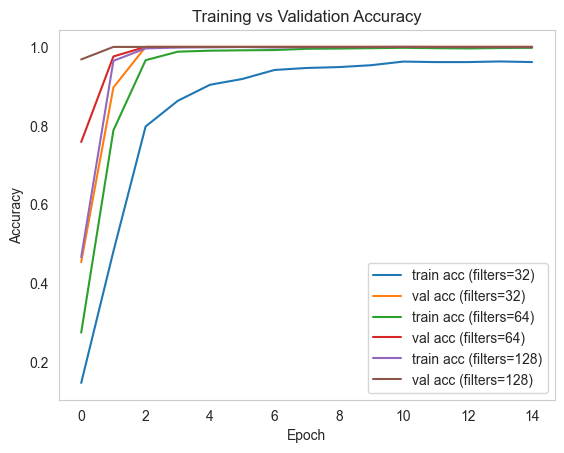

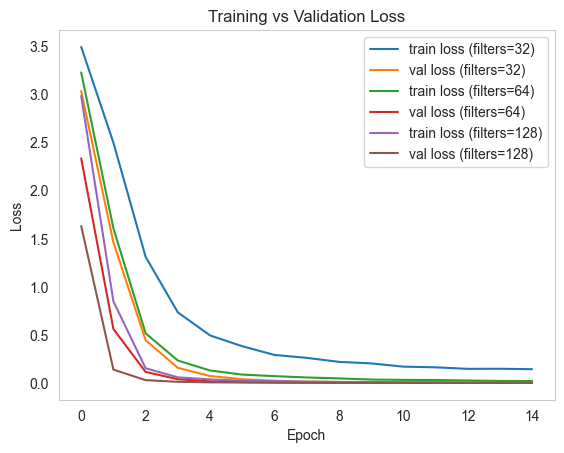

In [80]:
# Accuracy plot
plt.figure()

for i in histories:
    plt.plot(histories[i]["accuracy"],
             label=f"train acc (filters={filters[i]})")

    plt.plot(histories[i]["val_accuracy"],
             label=f"val acc (filters={filters[i]})")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


# Loss plot
plt.figure()

for i in histories:
    plt.plot(histories[i]["loss"],
             label=f"train loss (filters={filters[i]})")

    plt.plot(histories[i]["val_loss"],
             label=f"val loss (filters={filters[i]})")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

The accuracy and loss plots show that the neural network learns the dataset quickly and achieves high accuracy.
Increasing the number of filters improves the model slightly because the network can capture more complex patterns.
Dropout regularization helps reduce overfitting by preventing the model from relying too much on specific neurons.
Overall, the deep learning model performs very well on this dataset because the features are highly informative and the classes are easy to separate.